# Assignment 5 (Part A) — CIFAR-10 CNN Experiments (TensorFlow/Keras)


## 1) Imports + seed

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


TensorFlow: 2.20.0


## 2) Load CIFAR-10 + preprocess

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = y_train.squeeze()
y_test = y_test.squeeze()

num_classes = 10
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_test_oh = keras.utils.to_categorical(y_test, num_classes)

print("Train:", x_train.shape, y_train_oh.shape)
print("Test :", x_test.shape, y_test_oh.shape)


Train: (50000, 32, 32, 3) (50000, 10)
Test : (10000, 32, 32, 3) (10000, 10)


## 3) Train/validation split

In [3]:
from sklearn.model_selection import train_test_split

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train_oh, test_size=0.2, random_state=SEED, stratify=y_train
)

print("Train split:", x_tr.shape, y_tr.shape)
print("Val split  :", x_val.shape, y_val.shape)


Train split: (40000, 32, 32, 3) (40000, 10)
Val split  : (10000, 32, 32, 3) (10000, 10)


## 4) CPU-friendly subset (optional but recommended)

In [4]:
USE_SUBSET = True
TRAIN_N = 6000
VAL_N = 1500

if USE_SUBSET:
    x_tr_run, y_tr_run = x_tr[:TRAIN_N], y_tr[:TRAIN_N]
    x_val_run, y_val_run = x_val[:VAL_N], y_val[:VAL_N]
else:
    x_tr_run, y_tr_run = x_tr, y_tr
    x_val_run, y_val_run = x_val, y_val

print("Using train:", x_tr_run.shape, "val:", x_val_run.shape)


Using train: (6000, 32, 32, 3) val: (1500, 32, 32, 3)


## 5) Model builder (depth, BN, dropout, activation)

In [5]:
def activation_layer(name: str):
    name = name.lower()
    if name == "relu":
        return layers.Activation("relu")
    if name == "leakyrelu":
        return layers.LeakyReLU(alpha=0.1)
    if name == "elu":
        return layers.Activation("elu")
    raise ValueError(f"Unsupported activation: {name}")

def build_cnn(
    input_shape=(32, 32, 3),
    num_classes=10,
    num_blocks=3,
    base_filters=32,
    activation="relu",
    use_bn=False,
    dropout_rate=0.0,
):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    filters = base_filters

    for _ in range(num_blocks):
        x = layers.Conv2D(filters, 3, padding="same")(x)
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = activation_layer(activation)(x)

        x = layers.Conv2D(filters, 3, padding="same")(x)
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = activation_layer(activation)(x)

        x = layers.MaxPooling2D(2)(x)
        if dropout_rate and dropout_rate > 0:
            x = layers.Dropout(dropout_rate)(x)

        filters *= 2

    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    if use_bn:
        x = layers.BatchNormalization()(x)
    x = activation_layer(activation)(x)

    if dropout_rate and dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs)

build_cnn(num_blocks=3, activation="relu", use_bn=True, dropout_rate=0.3).summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 6) Train one configuration

In [6]:
def train_one_config(
    config_name: str,
    num_blocks: int,
    activation: str,
    use_bn: bool,
    dropout_rate: float,
    epochs: int = 3,
    batch_size: int = 256,
    lr: float = 1e-3,
):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)

    model = build_cnn(
        num_blocks=num_blocks,
        activation=activation,
        use_bn=use_bn,
        dropout_rate=dropout_rate,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=1, restore_best_weights=True),
        keras.callbacks.TerminateOnNaN(),
    ]

    history = model.fit(
        x_tr_run, y_tr_run,
        validation_data=(x_val_run, y_val_run),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks,
    )

    val_loss, val_acc = model.evaluate(x_val_run, y_val_run, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)

    return {
        "config": config_name,
        "num_blocks": num_blocks,
        "activation": activation,
        "batchnorm": use_bn,
        "dropout": dropout_rate,
        "val_accuracy": float(val_acc),
        "test_accuracy": float(test_acc),
        "epochs_ran": len(history.history["loss"]),
        "history": history.history,
    }


## 7) Experiment configs (meets all requirements)

In [7]:
configs = [
    ("baseline_b3_relu", 3, "relu", False, 0.0),
    ("bn_do_b3_relu",    3, "relu", True,  0.3),
    ("depth2_bn_do_relu", 2, "relu", True, 0.3),
    ("depth4_bn_do_relu", 4, "relu", True, 0.3),
    ("act_elu_bn_do",     3, "elu",  True, 0.3),
]

configs


[('baseline_b3_relu', 3, 'relu', False, 0.0),
 ('bn_do_b3_relu', 3, 'relu', True, 0.3),
 ('depth2_bn_do_relu', 2, 'relu', True, 0.3),
 ('depth4_bn_do_relu', 4, 'relu', True, 0.3),
 ('act_elu_bn_do', 3, 'elu', True, 0.3)]

## 8) Run experiments

In [8]:
results = []

for name, blocks, act, bn, dr in configs:
    print(f"Training: {name} | blocks={blocks}, act={act}, BN={bn}, dropout={dr}")
    out = train_one_config(
        config_name=name,
        num_blocks=blocks,
        activation=act,
        use_bn=bn,
        dropout_rate=dr,
        epochs=3,
        batch_size=256,
        lr=1e-3,
    )
    results.append(out)

results_df = pd.DataFrame([{k: v for k, v in r.items() if k != "history"} for r in results])
results_df = results_df.sort_values(by="val_accuracy", ascending=False).reset_index(drop=True)
results_df


Training: baseline_b3_relu | blocks=3, act=relu, BN=False, dropout=0.0
Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.1424 - loss: 2.2451 - val_accuracy: 0.3153 - val_loss: 1.8672
Epoch 2/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 231ms/step - accuracy: 0.3106 - loss: 1.8629 - val_accuracy: 0.3540 - val_loss: 1.7319
Epoch 3/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 327ms/step - accuracy: 0.3821 - loss: 1.6610 - val_accuracy: 0.4127 - val_loss: 1.6048
Training: bn_do_b3_relu | blocks=3, act=relu, BN=True, dropout=0.3
Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 369ms/step - accuracy: 0.2092 - loss: 2.3843 - val_accuracy: 0.0967 - val_loss: 2.4878
Epoch 2/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 400ms/step - accuracy: 0.3563 - loss: 1.7482 - val_accuracy: 0.0967 - val_loss: 2.9831
Training: depth2_bn_do_relu | blocks=2, act=relu, BN=True, dropout=0.3
Epoch 1/3
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.2592 - loss: 2.1995 - val_accuracy: 0.0967 - val_loss: 2.6656
Epoch 2/3
24/24 ━━━━━━━━━━━

,config,num_blocks,activation,batchnorm,dropout,val_accuracy,test_accuracy,epochs_ran
0,baseline_b3_relu,3,relu,False,0.0,0.412667,0.4159,3
1,act_elu_bn_do,3,elu,True,0.3,0.224000,0.2102,3
2,depth4_bn_do_relu,4,relu,True,0.3,0.101333,0.1053,3
3,bn_do_b3_relu,3,relu,True,0.3,0.096667,0.1000,2
4,depth2_bn_do_relu,2,relu,True,0.3,0.096667,0.1000,2


## 9) Plots

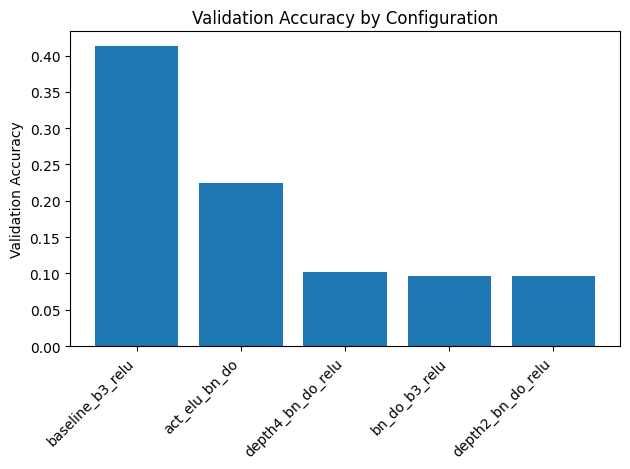

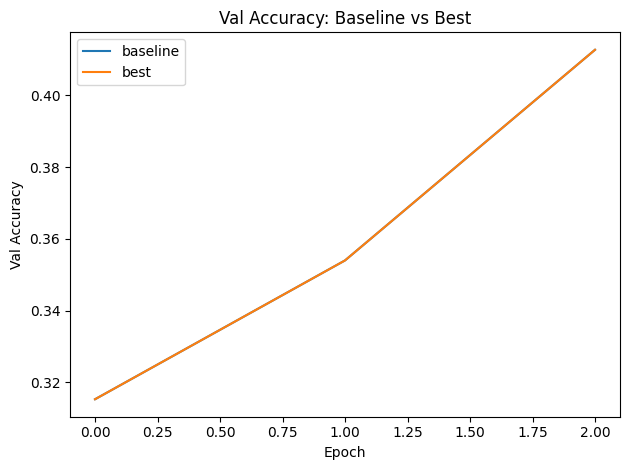

Best row:
config           baseline_b3_relu
num_blocks                      3
activation                   relu
batchnorm                   False
dropout                       0.0
val_accuracy             0.412667
test_accuracy              0.4159
epochs_ran                      3


In [9]:
plt.figure()
plt.bar(results_df["config"], results_df["val_accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy by Configuration")
plt.tight_layout()
plt.show()

baseline_name = "baseline_b3_relu"
best_name = results_df.iloc[0]["config"]

def get_hist(name):
    for r in results:
        if r["config"] == name:
            return r["history"]
    return None

hb = get_hist(baseline_name)
hbest = get_hist(best_name)

plt.figure()
plt.plot(hb["val_accuracy"], label="baseline")
plt.plot(hbest["val_accuracy"], label="best")
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("Val Accuracy: Baseline vs Best")
plt.legend()
plt.tight_layout()
plt.show()

print("Best row:")
print(results_df.iloc[0].to_string())
